# OSM/iduedu с топологией Arctic (только Regular road)

Эксперимент: граф из OSM/iduedu с **direct_edges_only** — рёбро A–C добавляется только если путь идёт напрямую (не через другое поселение B).
Цель — разреженный граф как в Arctic, только Regular road.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
ARCTIC_PATH = ROOT / "arctic_access"
DATA_PATH = ARCTIC_PATH / "data"

if str(ARCTIC_PATH) not in sys.path:
    sys.path.insert(0, str(ARCTIC_PATH))

from pipeline.config import SETTL_NAMES, SERVICE_NAME, RANGE_MONTHS, GRAPH_SOURCE

In [2]:
import geopandas as gpd
import pandas as pd
from transliterate import translit

def get_arctic_regular_road_pairs(data_path: str, settl_name: str) -> frozenset:
    """Пары (edge1, edge2) из df_time, где car_warm > 0 (Regular road)."""
    path = Path(data_path) / settl_name / f"df_time_{settl_name}.geojson"
    df = gpd.read_file(str(path))
    df = df.dropna(subset=["geometry"])
    
    for col in ["car_warm", "car_cold"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "."), errors="coerce").fillna(0)
    
    df["edge1"] = df["edge1"].str.replace("ё", "е").apply(lambda x: translit(x, "ru", reversed=True))
    df["edge2"] = df["edge2"].str.replace("ё", "е").apply(lambda x: translit(x, "ru", reversed=True))
    
    pairs = set()
    for _, row in df.iterrows():
        if row.get("car_warm", 0) > 0:
            a, b = row["edge1"], row["edge2"]
            pairs.add((a, b))
            pairs.add((b, a))
    return frozenset(pairs)

data_path = str(DATA_PATH / "processed") + "/"
settl_name = SETTL_NAMES[0]
whitelist = get_arctic_regular_road_pairs(data_path, settl_name)
print(f"Arctic Regular road pairs: {len(whitelist)//2}")
print("Sample:", list(whitelist)[:4])

Arctic Regular road pairs: 6
Sample: [('Dudinka', 'Tazovskij'), ('Tazovskij', "Noril'sk"), ("Noril'sk", 'Tazovskij'), ('Gaz-Sale', 'Tazovskij')]


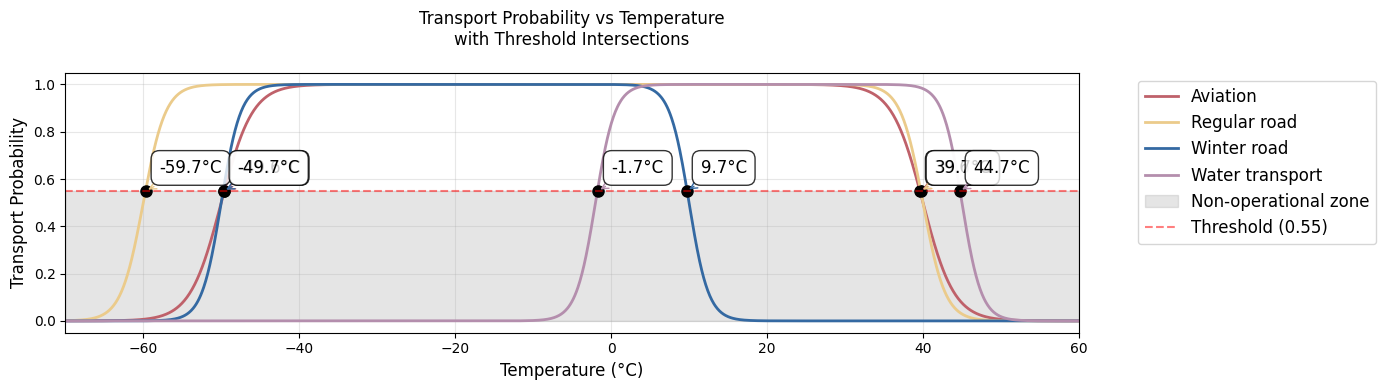

========== yanao_kras ==========


Running network analysis: 100%|██████████| 12/12 [00:01<00:00,  9.83it/s]


Arctic done: yanao_kras health


In [3]:
# Arctic (оригинал) — run_base
from pipeline import run_base

all_results_arctic, ctx_arctic = run_base.run()
print("Arctic done:", ctx_arctic["settl_name"], ctx_arctic["service_name"])

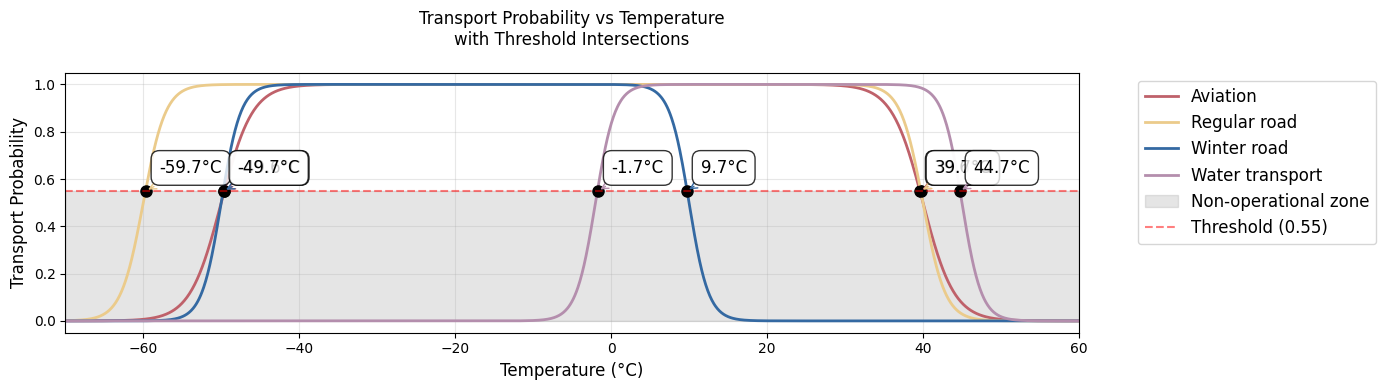

2026-03-14 15:38:46.382 | INFO     | Downloading drive network via Overpass ...
2026-03-14 15:38:46.415 | INFO     | Downloading network via Overpass done!


========== yanao_kras (OSM/iduedu) ==========


2026-03-14 15:38:47.237 | WARNING  | Removing 2285 nodes from 78 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (1305 nodes).
Running network analysis: 100%|██████████| 12/12 [00:00<00:00, 19.96it/s]


OSM done: yanao_kras health


In [4]:
# OSM с direct_edges_only — только прямые рёбра (путь не идёт через другое поселение)
from pipeline import run_base_osm

all_results_osm, ctx = run_base_osm.run()
settl_name = ctx["settl_name"]
service_name = ctx["service_name"]
print("OSM done:", settl_name, service_name)

In [5]:
# Сравнение формата all_results
def inspect_all_results(ar, label):
    sn = list(ar.keys())[0]
    ss = list(ar[sn].keys())[0]
    d = ar[sn][ss]
    G0 = d["graphs"][0]
    return {
        "label": label,
        "keys": list(d.keys()),
        "graphs_count": len(d["graphs"]),
        "graph0_nodes": G0.number_of_nodes(),
        "graph0_edges": G0.number_of_edges(),
        "records_shape": d["records"].shape,
        "results_count": len(d["results"]),
    }

a = inspect_all_results(all_results_arctic, "Arctic")
o = inspect_all_results(all_results_osm, "OSM")

print("=== Arctic ===")
for k, v in a.items():
    print(f"  {k}: {v}")
print("\n=== OSM (arctic topology) ===")
for k, v in o.items():
    print(f"  {k}: {v}")

print("\n=== Различия ===")
for k in a:
    if k != "label" and a[k] != o[k]:
        print(f"  {k}: Arctic={a[k]} vs OSM={o[k]}")

=== Arctic ===
  label: Arctic
  keys: ['net', 'stats', 'graphs', 'records', 'results', 'G_undirected', 'df_modes_monthly']
  graphs_count: 12
  graph0_nodes: 38
  graph0_edges: 132
  records_shape: (12, 7)
  results_count: 12

=== OSM (arctic topology) ===
  label: OSM
  keys: ['net', 'stats', 'graphs', 'records', 'results', 'G_undirected', 'df_modes_monthly']
  graphs_count: 12
  graph0_nodes: 12
  graph0_edges: 124
  records_shape: (12, 7)
  results_count: 12

=== Различия ===
  graph0_nodes: Arctic=38 vs OSM=12
  graph0_edges: Arctic=132 vs OSM=124


In [6]:
# Детали: records, results, рёбра графа
sn, ss = settl_name, service_name

print("=== records (первые строки) ===")
print("Arctic:")
print(all_results_arctic[sn][ss]["records"].head().to_string())
print("\nOSM:")
print(all_results_osm[sn][ss]["records"].head().to_string())

print("\n=== graph[0] — рёбра с assignment > 0 (синие) ===")
Ga = all_results_arctic[sn][ss]["graphs"][0]
Go = all_results_osm[sn][ss]["graphs"][0]
blue_arctic = [(u, v) for u, v, d in Ga.edges(data=True) if d.get("assignment", 0) > 0]
blue_osm = [(u, v) for u, v, d in Go.edges(data=True) if d.get("assignment", 0) > 0]
print(f"Arctic синих рёбер: {len(blue_arctic)}")
print(f"OSM синих рёбер: {len(blue_osm)}")

=== records (первые строки) ===
Arctic:
  idx  mean  min  max  median  Month  Year
0   0  0.82  0.0  1.0     1.0      1  1982
1   1  0.82  0.0  1.0     1.0      2  1982
2   2  0.82  0.0  1.0     1.0      3  1982
3   3  0.82  0.0  1.0     1.0      4  1982
4   4  0.82  0.0  1.0     1.0      5  1982

OSM:
  idx  mean  min  max  median  Month  Year
0   0   1.0  1.0  1.0     1.0      1  1982
1   1   1.0  1.0  1.0     1.0      2  1982
2   2   1.0  1.0  1.0     1.0      3  1982
3   3   1.0  1.0  1.0     1.0      4  1982
4   4   1.0  1.0  1.0     1.0      5  1982

=== graph[0] — рёбра с assignment > 0 (синие) ===
Arctic синих рёбер: 35
OSM синих рёбер: 12


In [7]:
# G_undirected — рёбра по режимам (Arctic: Aviation, Road, Winter, Water; OSM: только Regular road)
Ga = all_results_arctic[sn][ss]["G_undirected"]
Go = all_results_osm[sn][ss]["G_undirected"]

from collections import Counter
def edge_modes(G):
    modes = []
    for u, v, d in G.edges(data=True):
        modes.append(d.get("label", "?"))
    return Counter(modes)

print("Arctic рёбра по режимам:", dict(edge_modes(Ga)))
print("OSM рёбра по режимам:", dict(edge_modes(Go)))

Arctic рёбра по режимам: {'Aviation': 62, 'Water transport': 94, 'Winter road': 48, 'Regular road': 12}
OSM рёбра по режимам: {'Regular road': 228}


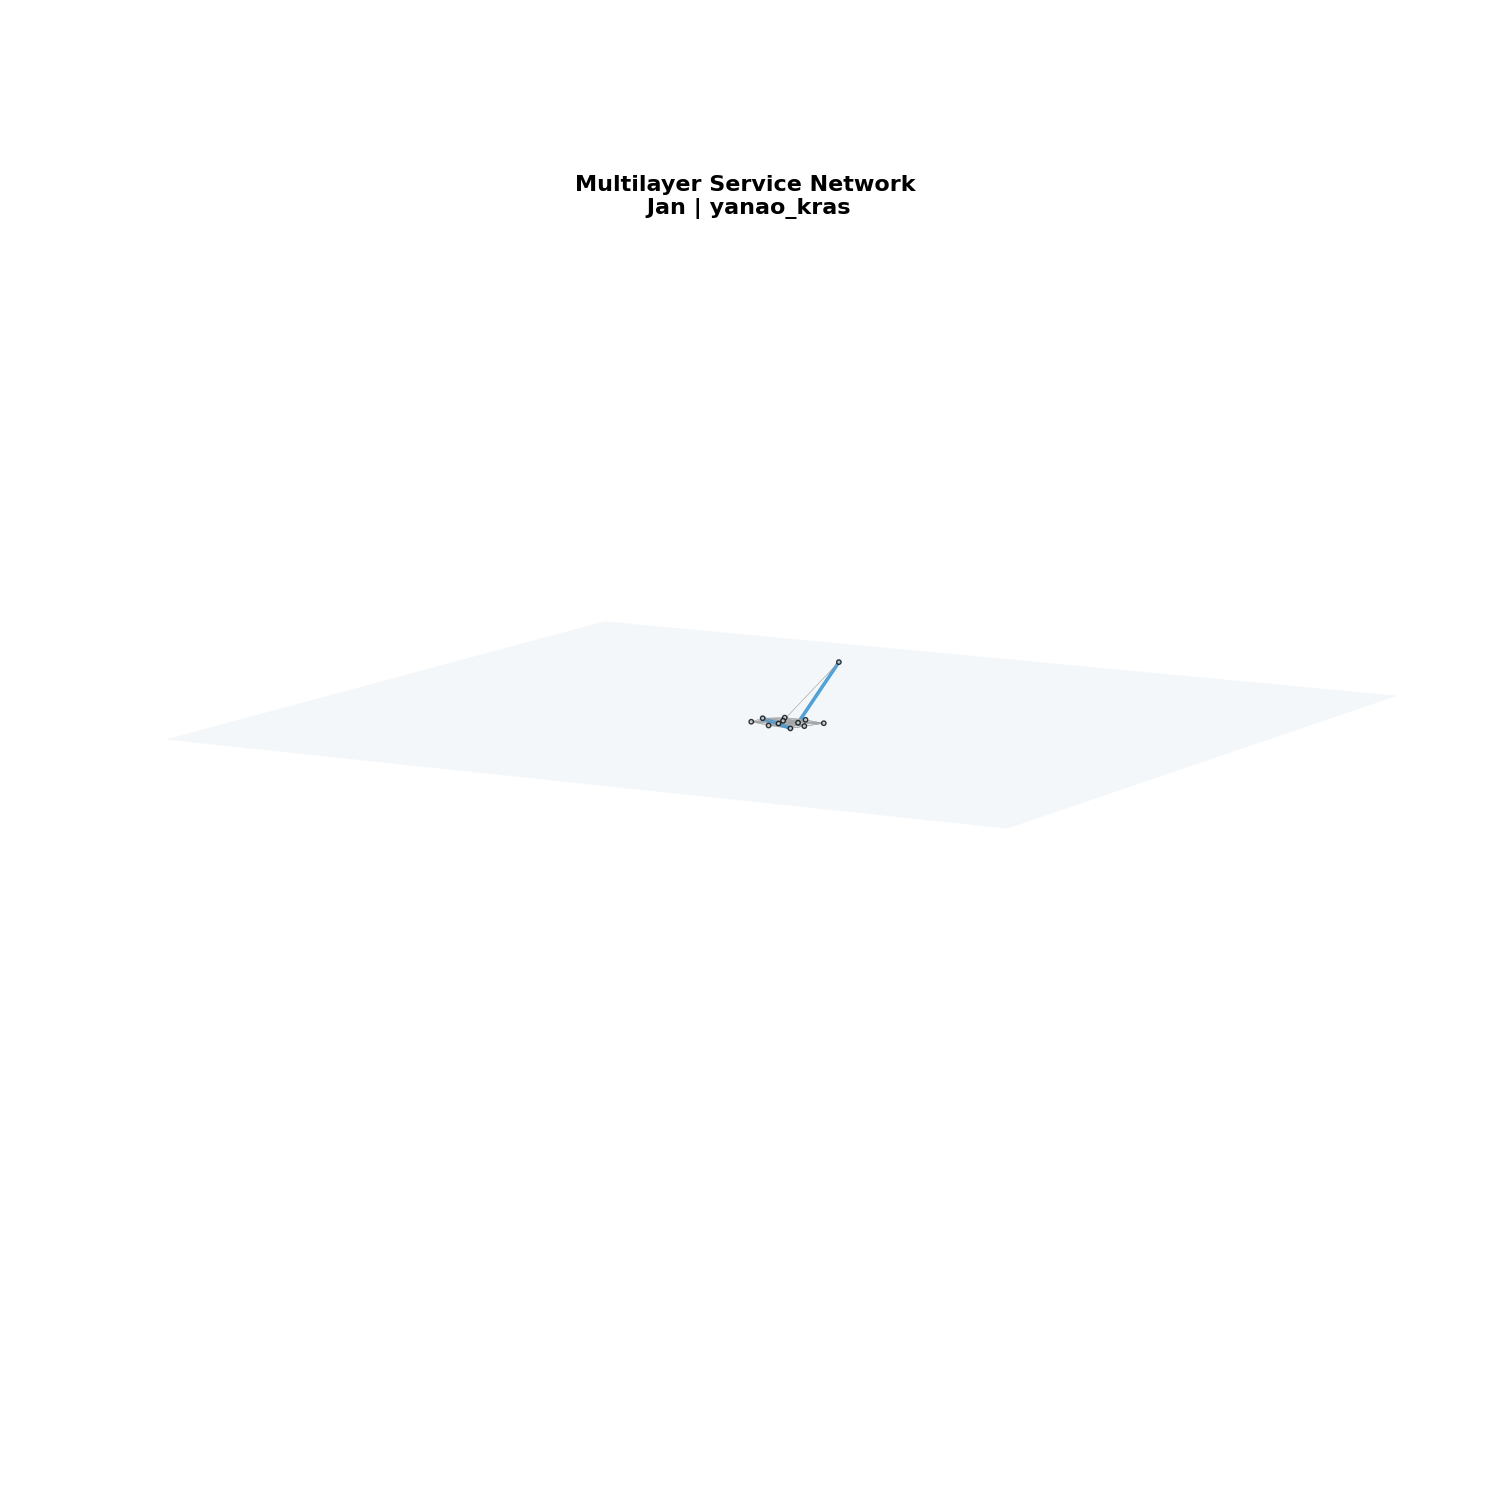

In [8]:
from pipeline import run_plots

_ = run_plots.multilayer(all_results_osm, settl_name)

In [9]:
all_results

NameError: name 'all_results' is not defined

In [ ]:
# Multilayer с географическим layout (как в оригинале Arctic)
import numpy as np
import matplotlib.pyplot as plt
from scripts.preprocesser.constants import SERVICE_COLORS, month_order

def multilayer_geo(all_results, settl_name, service_name, month=0, figsize=(15, 30)):
    """Multilayer с pos из geometry (x,y) — одинаковый layout для Arctic и OSM."""
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    layer_height = 2.0
    layer_alpha = 0.05

    nx_graph = all_results[settl_name][service_name]["graphs"][month]
    all_nodes = list(nx_graph.nodes())

    # Географический layout из node x,y (Mercator)
    pos = {}
    xs, ys = [], []
    for n in all_nodes:
        x = nx_graph.nodes[n].get("x")
        y = nx_graph.nodes[n].get("y")
        if x is not None and y is not None:
            pos[n] = (float(x), float(y))
            xs.append(x)
            ys.append(y)
    if not pos:
        pos = {n: (0, 0) for n in all_nodes}
    else:
        # Нормализация в диапазон ~(-8, 8)
        xs, ys = np.array(xs), np.array(ys)
        xmin, xmax = xs.min(), xs.max()
        ymin, ymax = ys.min(), ys.max()
        for n in pos:
            x, y = pos[n]
            pos[n] = (
                16 * (x - xmin) / max(xmax - xmin, 1e-6) - 8,
                16 * (y - ymin) / max(ymax - ymin, 1e-6) - 8,
            )

    color = SERVICE_COLORS.get(service_name, "#5E81AC")
    z = 0
    xx, yy = np.meshgrid(np.linspace(-8, 8, 20), np.linspace(-8, 8, 20))
    ax.plot_surface(xx, yy, np.ones_like(xx) * z, alpha=layer_alpha, color=color, linewidth=0)

    node_x, node_y, node_z = [], [], []
    node_colors, node_sizes = [], []
    for node in all_nodes:
        if node in pos:
            x, y = pos[node]
            node_x.append(x)
            node_y.append(y)
            node_z.append(z)
            cap = nx_graph.nodes[node].get(f"capacity_{service_name}", 0)
            node_colors.append(color if cap > 0 else "lightgray")
            node_sizes.append(200 if cap > 0 else 10)
    ax.scatter(node_x, node_y, node_z, c=node_colors, s=node_sizes, alpha=0.8, edgecolors="black", linewidth=1.0)

    for u, v, data in nx_graph.edges(data=True):
        if u in pos and v in pos:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            w = 2.5 if data.get("assignment", 0) > 0 else 0.3
            c = color if data.get("assignment", 0) > 0 else "darkgray"
            ax.plot([x1, x2], [y1, y2], [z, z], color=c, linewidth=w, alpha=0.9)

    ax.view_init(elev=10, azim=30)
    ax.set_xlim(-8, 10)
    ax.set_ylim(-8, 8)
    ax.set_axis_off()
    plt.title(f"Multilayer Service Network (geo layout)\n{month_order[month]} | {settl_name}", fontsize=16, weight="bold", y=0.93)
    plt.tight_layout()
    return fig

_ = multilayer_geo(all_results_osm, settl_name, service_name, month=0)